In [6]:
# Experiment 3a1 Lambda Sweep Overfitting Audit (NLP)
# This notebook is dedicated to a question: when budget increases (lambda decreases), why can `kernel_pier` go up?
# It diagnoses two things:
# - non-monotonicity of eval PIER vs budget
# - potential overfitting via `overfit_gap = kernel_pier_eval - kernel_pier_fit`
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.figsize': (7, 4.8),
    'figure.dpi': 150,
})

tbl = Path('../results/tables').resolve()
art = Path('../results/artifacts').resolve()
art.mkdir(parents=True, exist_ok=True)
csv_path = tbl / 'exp3a1_bert_lambda_overfit.csv'
csv_path


PosixPath('/Users/zsh/GITHUBPROJECTS/毕设/KERNEL-PIER/results/tables/exp3a1_bert_lambda_overfit.csv')

In [7]:
df = pd.read_csv(csv_path)
df = df.sort_values(['target_model', 'budget']).reset_index(drop=True)
print('rows:', len(df), '| targets:', df['target_model'].nunique(), '| lambdas:', df['lambda'].nunique())
display(df.head())

summary = df.groupby('target_model', as_index=False).agg(
    convex_pier=('convex_pier', 'mean'),
    best_eval=('kernel_pier_eval', 'min'),
    mean_overfit_gap=('overfit_gap', 'mean'),
    eval_rise_count=('eval_rise_count', 'max'),
)
summary


rows: 36 | targets: 3 | lambdas: 12


,target_model,target_group,theta,lambda,budget,convex_fit_distance,convex_pier_fit,convex_pier,kernel_pier_eval,kernel_pier_fit,...,target_model_revision,peer_model_ids,peer_model_revisions,monotonic_tol,eval_delta_vs_prev,fit_delta_vs_prev,eval_increase_vs_prev,fit_increase_vs_prev,eval_rise_count,fit_rise_count
0,Architectural Divergence (RoBERTa),Low Redundancy,0.5,3.00,0.333333,1.713601,0.095165,0.11673,0.152502,0.142564,...,84ee248b91053ef5d0c748bbac4edfba1cf89584,textattack/bert-base-uncased-SST-2|textattack/...,95f0f6f859b35c8ff0863ae3cd4e2dbc702c0ae2|6fea1...,0.0001,NaN,NaN,0,0,9,0
1,Architectural Divergence (RoBERTa),Low Redundancy,0.5,1.00,1.000000,1.713601,0.095165,0.11673,0.128951,0.116279,...,84ee248b91053ef5d0c748bbac4edfba1cf89584,textattack/bert-base-uncased-SST-2|textattack/...,95f0f6f859b35c8ff0863ae3cd4e2dbc702c0ae2|6fea1...,0.0001,-0.023551,-0.026285,0,0,9,0
2,Architectural Divergence (RoBERTa),Low Redundancy,0.5,0.30,3.333333,1.713601,0.095165,0.11673,0.120836,0.099050,...,84ee248b91053ef5d0c748bbac4edfba1cf89584,textattack/bert-base-uncased-SST-2|textattack/...,95f0f6f859b35c8ff0863ae3cd4e2dbc702c0ae2|6fea1...,0.0001,-0.008114,-0.017229,0,0,9,0
3,Architectural Divergence (RoBERTa),Low Redundancy,0.5,0.10,10.000000,1.713601,0.095165,0.11673,0.120981,0.086687,...,84ee248b91053ef5d0c748bbac4edfba1cf89584,textattack/bert-base-uncased-SST-2|textattack/...,95f0f6f859b35c8ff0863ae3cd4e2dbc702c0ae2|6fea1...,0.0001,0.000144,-0.012363,1,0,9,0
4,Architectural Divergence (RoBERTa),Low Redundancy,0.5,0.03,33.333333,1.713601,0.095165,0.11673,0.127232,0.077327,...,84ee248b91053ef5d0c748bbac4edfba1cf89584,textattack/bert-base-uncased-SST-2|textattack/...,95f0f6f859b35c8ff0863ae3cd4e2dbc702c0ae2|6fea1...,0.0001,0.006251,-0.009360,1,0,9,0


,target_model,convex_pier,best_eval,mean_overfit_gap,eval_rise_count
0,Architectural Divergence (RoBERTa),0.116730,0.120836,0.064968,9
1,Parametric Divergence (Finetuned),0.108362,0.113617,0.051763,8
2,Perfect Redundancy (Clone),0.000002,0.004489,0.003605,0


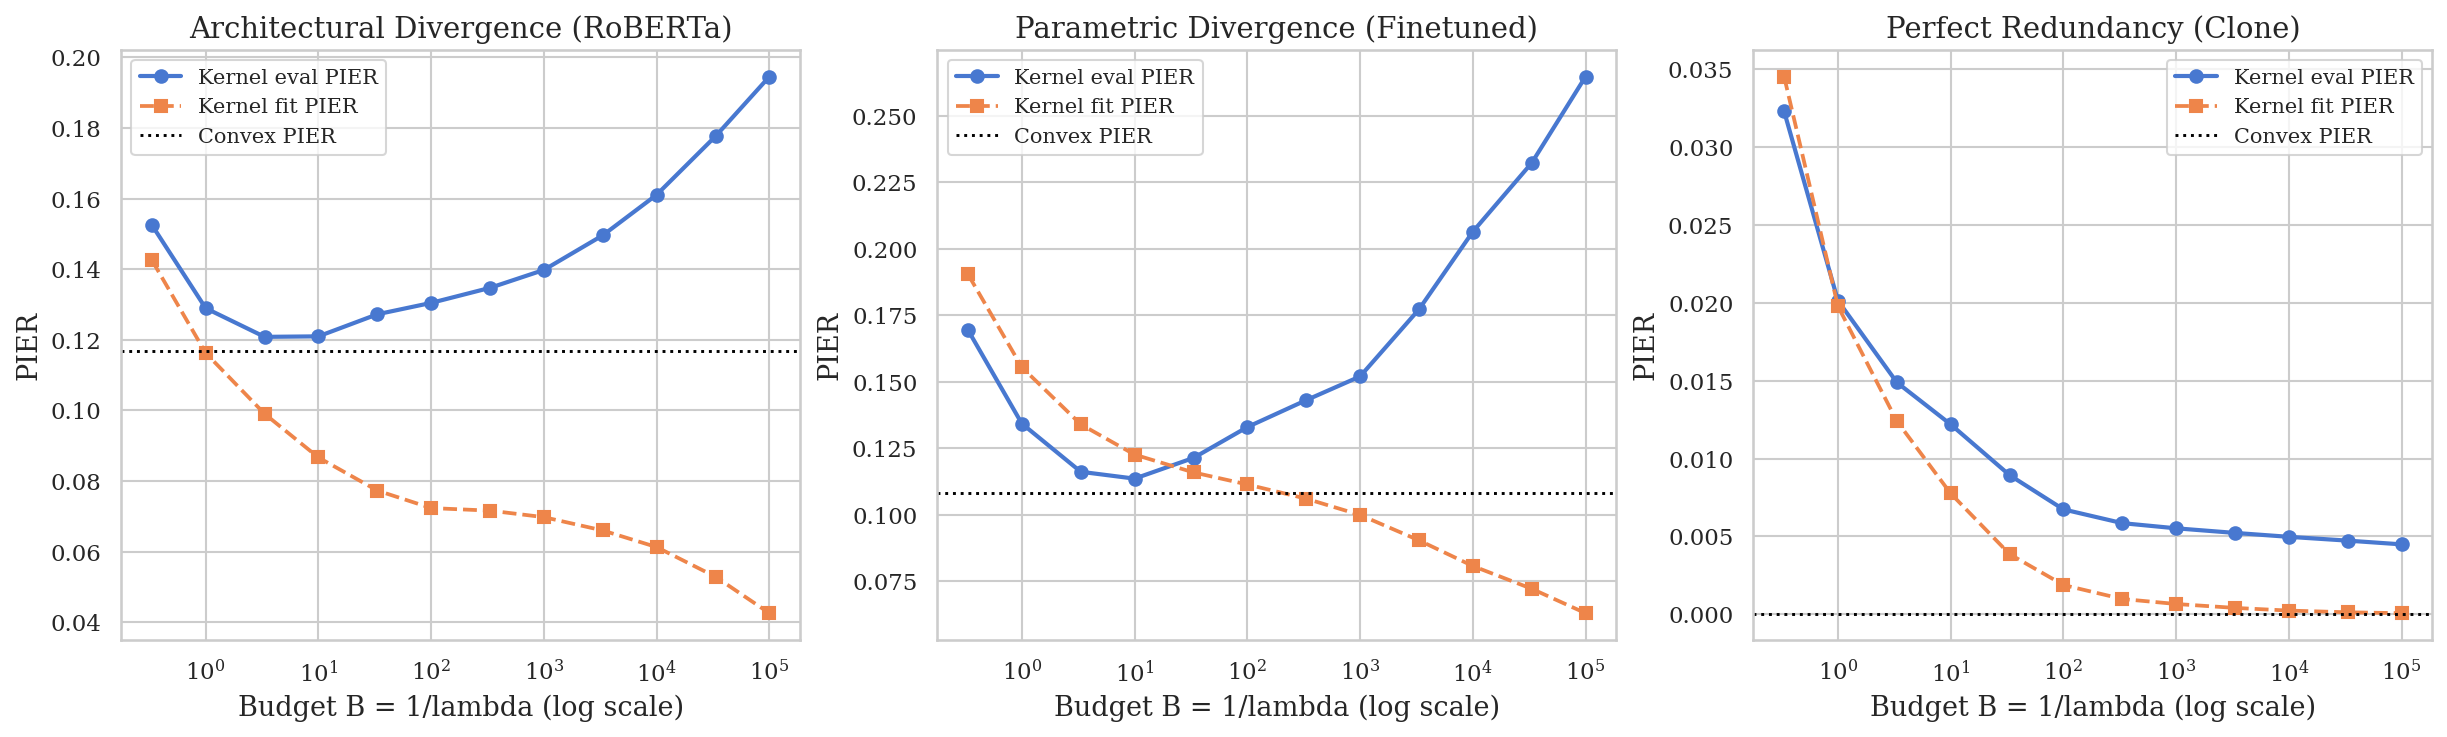

In [8]:
targets = list(df['target_model'].unique())
n = len(targets)
fig, axes = plt.subplots(1, n, figsize=(5.4 * n, 4.8), sharey=False, constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, t in zip(axes, targets):
    sub = df[df['target_model'] == t].sort_values('budget')
    ax.plot(sub['budget'], sub['kernel_pier_eval'], marker='o', lw=2.0, label='Kernel eval PIER')
    ax.plot(sub['budget'], sub['kernel_pier_fit'], marker='s', lw=1.8, linestyle='--', label='Kernel fit PIER')
    ax.axhline(float(sub['convex_pier'].iloc[0]), color='black', linestyle=':', lw=1.4, label='Convex PIER')
    ax.set_xscale('log')
    ax.set_xlabel('Budget B = 1/lambda (log scale)')
    ax.set_ylabel('PIER')
    ax.set_title(t)
    ax.legend(loc='best')

plt.savefig(art / 'exp3a1_budget_vs_fit_eval_pier.pdf', bbox_inches='tight')
plt.show()


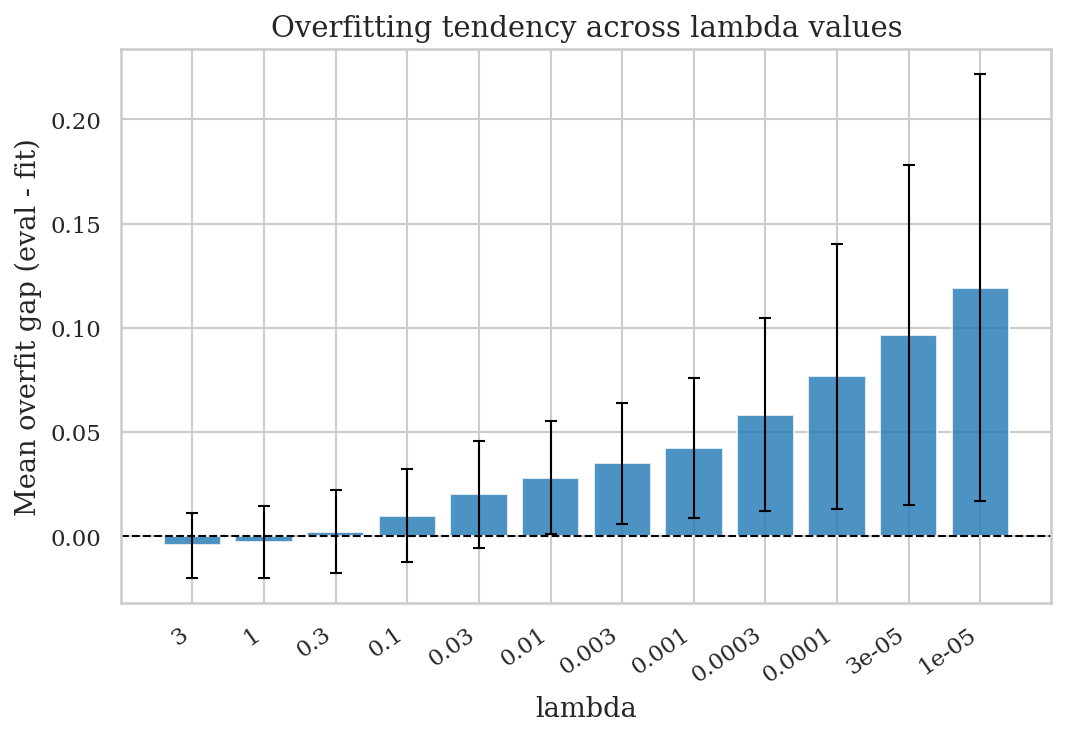

In [9]:
agg_gap = df.groupby('lambda', as_index=False).agg(
    gap_mu=('overfit_gap', 'mean'),
    gap_sd=('overfit_gap', 'std'),
)
agg_gap = agg_gap.sort_values('lambda', ascending=False)

fig, ax = plt.subplots(figsize=(8.0, 4.8))
x = np.arange(len(agg_gap))
y = agg_gap['gap_mu'].to_numpy()
s = agg_gap['gap_sd'].fillna(0.0).to_numpy()
ax.bar(x, y, color='tab:blue', alpha=0.8)
ax.errorbar(x, y, yerr=s, fmt='none', ecolor='black', capsize=3, lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f'{v:g}' for v in agg_gap['lambda']], rotation=35, ha='right')
ax.set_xlabel('lambda')
ax.set_ylabel('Mean overfit gap (eval - fit)')
ax.set_title('Overfitting tendency across lambda values')
ax.axhline(0.0, color='black', linestyle='--', lw=1)
plt.savefig(art / 'exp3a1_overfit_gap_by_lambda.pdf', bbox_inches='tight')
plt.show()


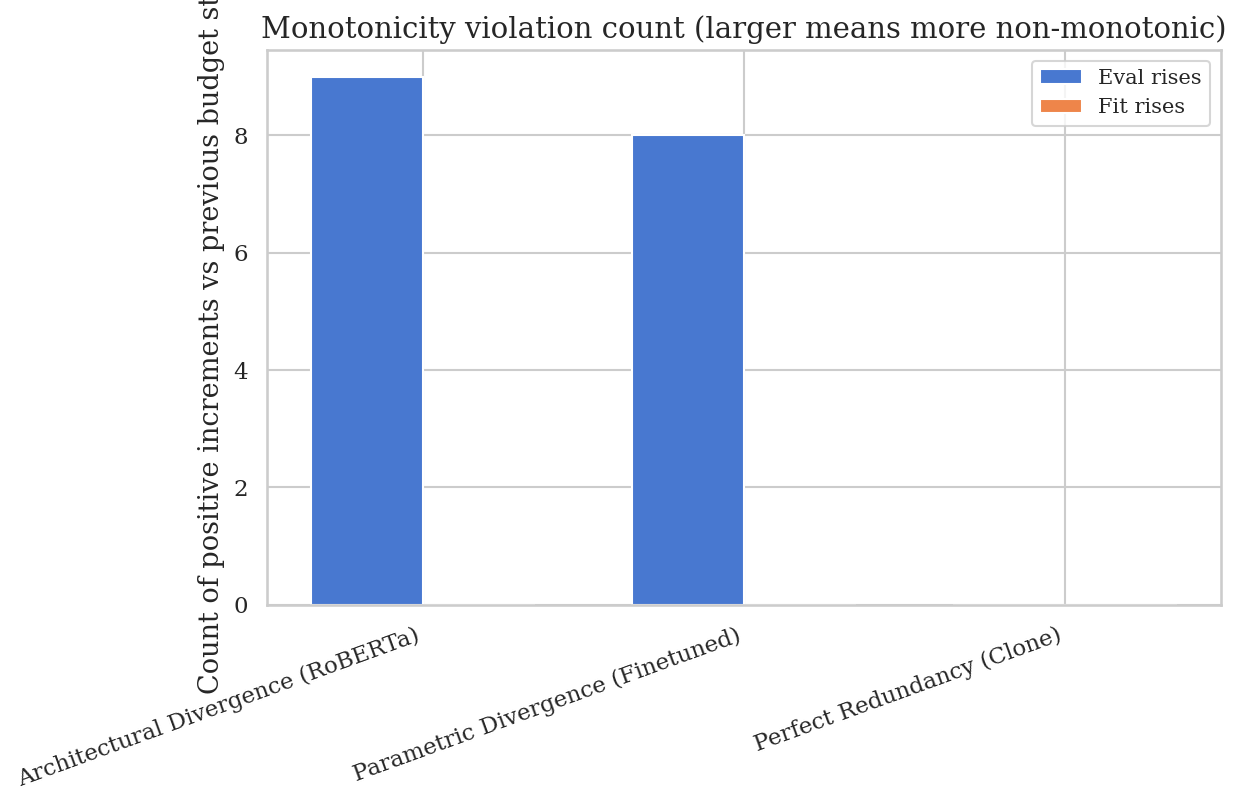

In [10]:
rise = df[['target_model', 'eval_rise_count', 'fit_rise_count']].drop_duplicates().sort_values('target_model')
fig, ax = plt.subplots(figsize=(8.2, 4.8))
x = np.arange(len(rise))
w = 0.35
ax.bar(x - w / 2, rise['eval_rise_count'], width=w, label='Eval rises')
ax.bar(x + w / 2, rise['fit_rise_count'], width=w, label='Fit rises')
ax.set_xticks(x)
ax.set_xticklabels(rise['target_model'], rotation=20, ha='right')
ax.set_ylabel('Count of positive increments vs previous budget step')
ax.set_title('Monotonicity violation count (larger means more non-monotonic)')
ax.legend(loc='best')
plt.savefig(art / 'exp3a1_monotonic_violation_counts.pdf', bbox_inches='tight')
plt.show()
